# The Core Machine Learning Pipeline

---

This section contains the main, sequential workflow, from loading the data and applying PCA to training, evaluating, and comparing the final models.

### **Block 1 : Importing libraries and preparing the work environment**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)
pd.set_option('display.float_format', '{:.5f}'.format)

**Block 2 : Mount Google Drive to access the project files**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Block 3: Memory-Safe Data Loading and Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import os

# Define File Path
csv_file_path_in_drive = '/content/drive/MyDrive/dataset-DDoS/unzipped/merged_CSVs.csv'

# Load and Clean
chunksize = 100000
reader = pd.read_csv(
    csv_file_path_in_drive,
    chunksize=chunksize,
    encoding='latin1',
    low_memory=False
)

cleaned_chunks = []
print(f"Starting to process and clean the file in chunks of {chunksize} rows...")
chunk_num = 0

for chunk in reader:
    chunk_num += 1
    print(f"Processing and cleaning chunk {chunk_num}...")


    # Coerce all columns (except 'label') to numeric, turning errors into NaN
    for col in chunk.columns:
        if col != 'label':
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

    # Replace infinite values with NaN
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop rows with NaN in critical columns (removes headers and bad rows)
    chunk.dropna(subset=['duration', 'packets_count'], inplace=True)

    # Fill any remaining NaNs with 0
    chunk.fillna(0, inplace=True)

    cleaned_chunks.append(chunk)

print("\nAll chunks processed. Concatenating them into the final DataFrame")
df = pd.concat(cleaned_chunks, ignore_index=True)

print("Dataset loaded AND cleaned successfully!")
df.info(memory_usage='deep')

Starting to process and clean the file in chunks of 100000 rows...
Processing and cleaning chunk 1...
Processing and cleaning chunk 2...
Processing and cleaning chunk 3...
Processing and cleaning chunk 4...
Processing and cleaning chunk 5...
Processing and cleaning chunk 6...
Processing and cleaning chunk 7...
Processing and cleaning chunk 8...

All chunks processed. Concatenating them into the final DataFrame
Dataset loaded AND cleaned successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700774 entries, 0 to 700773
Columns: 324 entries, flow_id to activity
dtypes: float64(323), object(1)
memory usage: 1.7 GB


**Block 4: Display Column Names**

In [ ]:
column_names = df.columns.tolist()

print("All Column Names ")
print(column_names)

print(f"\nTotal number of columns: {len(column_names)}")

All Column Names 
['flow_id', 'timestamp', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'duration', 'packets_count', 'fwd_packets_count', 'bwd_packets_count', 'total_payload_bytes', 'fwd_total_payload_bytes', 'bwd_total_payload_bytes', 'payload_bytes_max', 'payload_bytes_min', 'payload_bytes_mean', 'payload_bytes_std', 'payload_bytes_variance', 'payload_bytes_median', 'payload_bytes_skewness', 'payload_bytes_cov', 'payload_bytes_mode', 'fwd_payload_bytes_max', 'fwd_payload_bytes_min', 'fwd_payload_bytes_mean', 'fwd_payload_bytes_std', 'fwd_payload_bytes_variance', 'fwd_payload_bytes_median', 'fwd_payload_bytes_skewness', 'fwd_payload_bytes_cov', 'fwd_payload_bytes_mode', 'bwd_payload_bytes_max', 'bwd_payload_bytes_min', 'bwd_payload_bytes_mean', 'bwd_payload_bytes_std', 'bwd_payload_bytes_variance', 'bwd_payload_bytes_median', 'bwd_payload_bytes_skewness', 'bwd_payload_bytes_cov', 'bwd_payload_bytes_mode', 'total_header_bytes', 'max_header_bytes', 'min_header_bytes', 'mean_h

**Block 5: Feature Engineering and Data Preparation**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
target_column = 'label'
columns_to_drop = ['flow_id', 'timestamp', 'src_ip', 'dst_ip', 'activity']
y_raw = df[target_column]
X_raw = df.drop(columns=columns_to_drop + [target_column])

# 2. Encode the Target Variable
label_mapping = {'Benign': 0, 'Attack': 1, 'Suspicious': 2}
y_multiclass = y_raw.map(label_mapping).astype(int)

# 3. Scale the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 4. Split the Data into Training (70%), Validation (15%), and Test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_multiclass, test_size=0.3, random_state=42, stratify=y_multiclass
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Data prepared, scaled, and split successfully")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Data prepared, scaled, and split successfully
Training set shape: (490541, 318)
Validation set shape: (105116, 318)
Test set shape: (105117, 318)


**Block 6: Dimensionality Reduction with PCA**

Applying PCA on the split data 
PCA applied successfully
Original number of features: 318
Reduced number of features: 56
New shape of training data: (490541, 56)


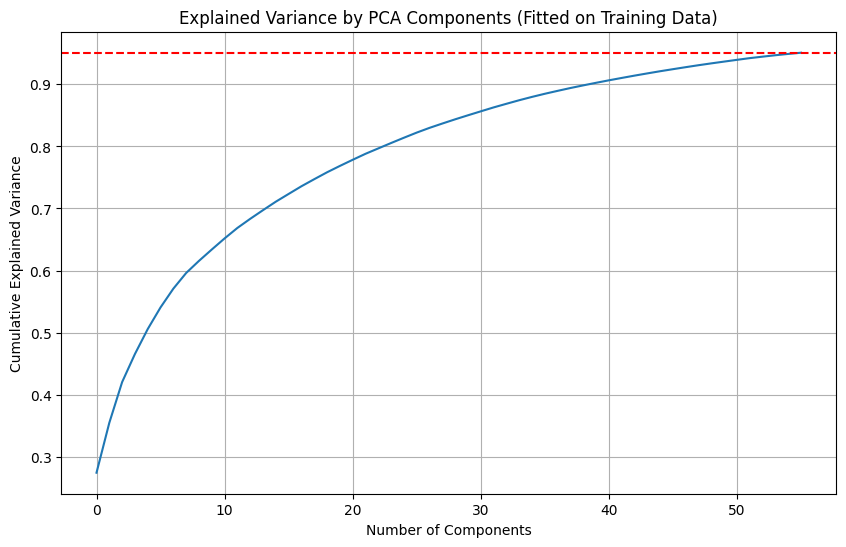

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

print("Applying PCA on the split data ")
# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95)

# Fit PCA on the TRAINING data and then transform it
X_train_pca = pca.fit_transform(X_train)

# Use the SAME fitted PCA to transform the validation and test data
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print("PCA applied successfully")
print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {pca.n_components_}")
print(f"New shape of training data: {X_train_pca.shape}")

# Visualize the Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Explained Variance by PCA Components (Fitted on Training Data)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

**Block 7: Model Training on a Safe Subsample**

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import time

# --- Step 1: Create a smaller, representative subsample for training ---
# We take a sample from the PCA-transformed training data to avoid memory crashes.
# 80,000 samples is large enough to build a good model but small enough to be safe.
print("Creating a smaller subsample for training to prevent crashes ")
_, X_train_sample, _, y_train_sample = train_test_split(
    X_train_pca, y_train,
    test_size=80000, # The size of our new training sample
    random_state=42,
    stratify=y_train
)
print(f"New training sample shape: {X_train_sample.shape}")


# --- Step 2: Train the models on the smaller sample ---
# We will train on the new, smaller sample
X_train_to_use = X_train_sample
y_train_to_use = y_train_sample

models = {
    'Hybrid PCA-SVM': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced')
}

trained_models = {}

print("\n Training All Models on the Subsample ")
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train_to_use, y_train_to_use)
    end_time = time.time()
    trained_models[name] = model
    print(f"{name} trained in {end_time - start_time:.2f} seconds.")

Creating a smaller subsample for training to prevent crashes 
New training sample shape: (80000, 56)

 Training All Models on the Subsample 
Training Hybrid PCA-SVM...
Hybrid PCA-SVM trained in 3711.12 seconds.
Training Random Forest...
Random Forest trained in 137.48 seconds.
Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression trained in 62.16 seconds.


**Block 8: Final Evaluation and Comparison**


--- Evaluating Models on the Unseen Test Set ---

----- Results for Hybrid PCA-SVM -----

--- Evaluating Models on the Unseen Test Set ---

----- Results for Hybrid PCA-SVM -----
                precision    recall  f1-score   support

    Benign (0)       0.91      0.96      0.94     61980
    Attack (1)       0.99      0.60      0.74     34271
Suspicious (2)       0.34      0.74      0.47      8866

      accuracy                           0.82    105117
     macro avg       0.75      0.77      0.72    105117
  weighted avg       0.89      0.82      0.83    105117


----- Results for Random Forest -----
                precision    recall  f1-score   support

    Benign (0)       0.91      0.96      0.94     61980
    Attack (1)       0.99      0.60      0.74     34271
Suspicious (2)       0.34      0.74      0.47      8866

      accuracy                           0.82    105117
     macro avg       0.75      0.77      0.72    105117
  weighted avg       0.89      0.82      0.83   

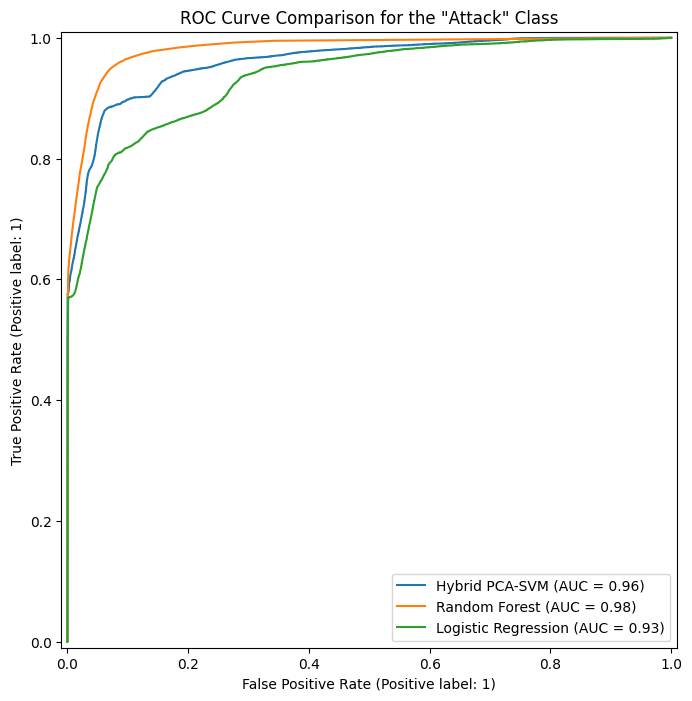

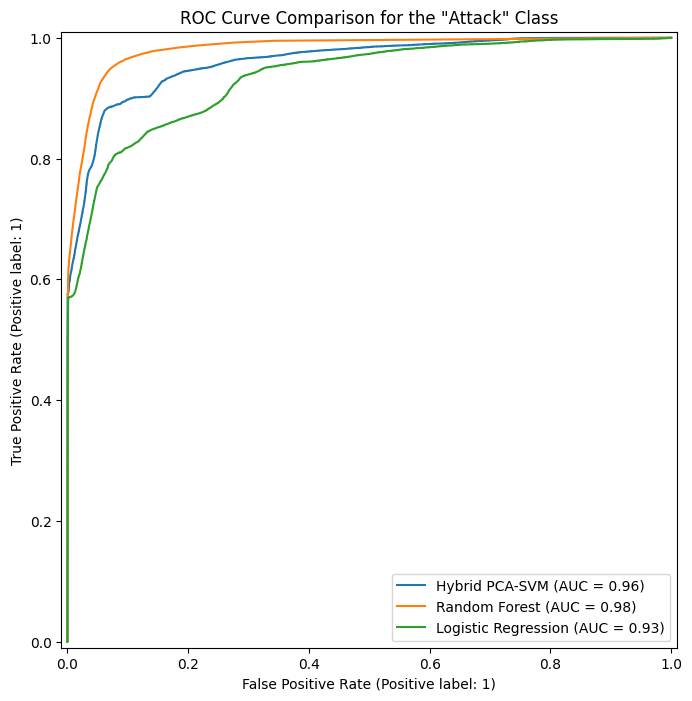

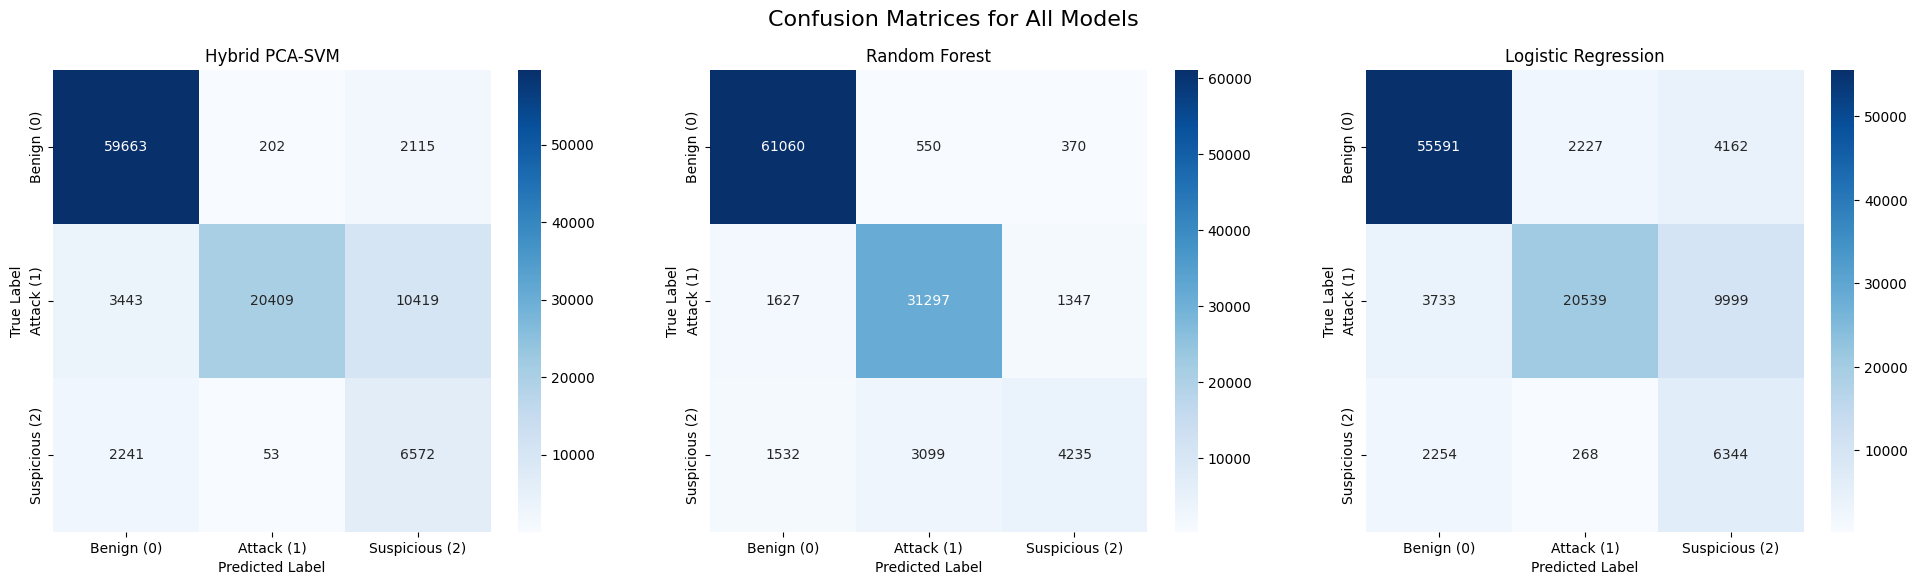


--- Final Model Comparison Summary ---
                     Accuracy  Precision (Attack)  Recall (Attack)  \
Random Forest         0.91890             0.89558          0.91322   
Hybrid PCA-SVM        0.82426             0.98766          0.59552   
Logistic Regression   0.78459             0.89168          0.59931   

                     F1-Score (Attack)  
Random Forest                  0.90432  
Hybrid PCA-SVM                 0.74302  
Logistic Regression            0.71683  


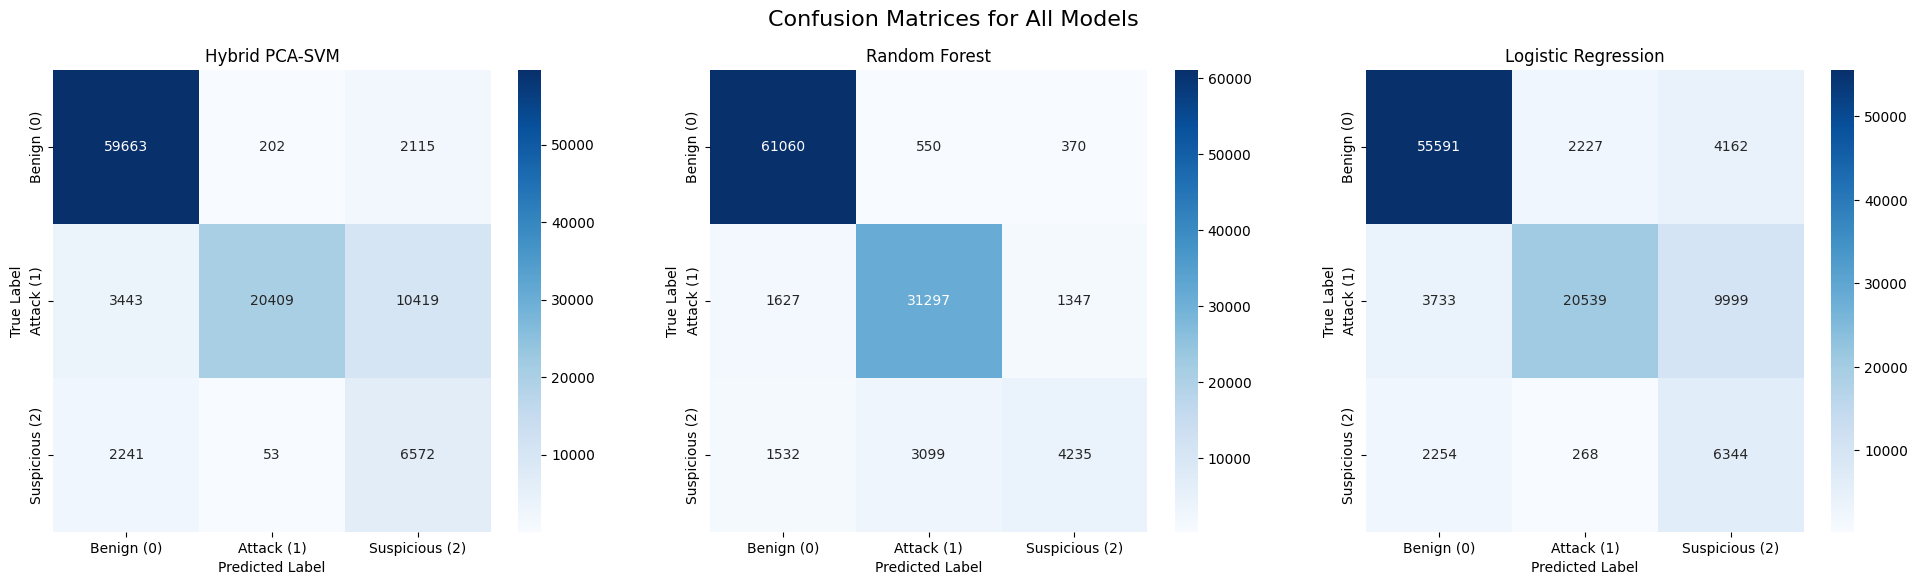


--- Final Model Comparison Summary ---
                     Accuracy  Precision (Attack)  Recall (Attack)  \
Random Forest         0.91890             0.89558          0.91322   
Hybrid PCA-SVM        0.82426             0.98766          0.59552   
Logistic Regression   0.78459             0.89168          0.59931   

                     F1-Score (Attack)  
Random Forest                  0.90432  
Hybrid PCA-SVM                 0.74302  
Logistic Regression            0.71683  


In [ ]:
# --- Block 8: Final Evaluation and Comparison ---
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, RocCurveDisplay, confusion_matrix
import pandas as pd

results = {}
class_names = ['Benign (0)', 'Attack (1)', 'Suspicious (2)']

print("\n--- Evaluating Models on the Unseen Test Set ---")

# --- 1. Classification Reports ---
for name, model in trained_models.items():
    print(f"\n----- Results for {name} -----")
    predictions = model.predict(X_test_pca)
    print(classification_report(y_test, predictions, target_names=class_names))
    # Store metrics for the summary table
    report = classification_report(y_test, predictions, target_names=class_names, output_dict=True)
    results[name] = {
        'Accuracy': report['accuracy'],
        'Precision (Attack)': report['Attack (1)']['precision'],
        'Recall (Attack)': report['Attack (1)']['recall'],
        'F1-Score (Attack)': report['Attack (1)']['f1-score']
    }

# --- 2. ROC Curve Comparison ---
fig, ax = plt.subplots(figsize=(10, 8))
from sklearn.preprocessing import label_binarize
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test_binarized[:, 1], y_prob[:, 1])
    RocCurveDisplay.from_predictions(y_test_binarized[:, 1], y_prob[:, 1], name=name, ax=ax)
ax.set_title('ROC Curve Comparison for the "Attack" Class')
plt.show()

# --- 3. Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Confusion Matrices for All Models', fontsize=16)
for ax, (name, model) in zip(axes.flatten(), trained_models.items()):
    predictions = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.show()

# --- 4. Final Summary Table ---
summary_df = pd.DataFrame(results).T.sort_values(by='F1-Score (Attack)', ascending=False)
print("\n--- Final Model Comparison Summary ---")
print(summary_df)

# Appendix: Theoretical Linear Algebra

---

This section contains all the blocks that demonstrate the mathematical concepts manually, such as calculating the covariance matrix, solving equations, and comparing simple vs. advanced models. It serves as the theoretical proof that supports the practical results in the first part.

**Appendix Block A: Calculate and Visualize the Covariance Matrix**

--- Step A: Calculating the Covariance Matrix ---
Covariance Matrix calculated successfully.
Shape of the covariance matrix: (10, 10)


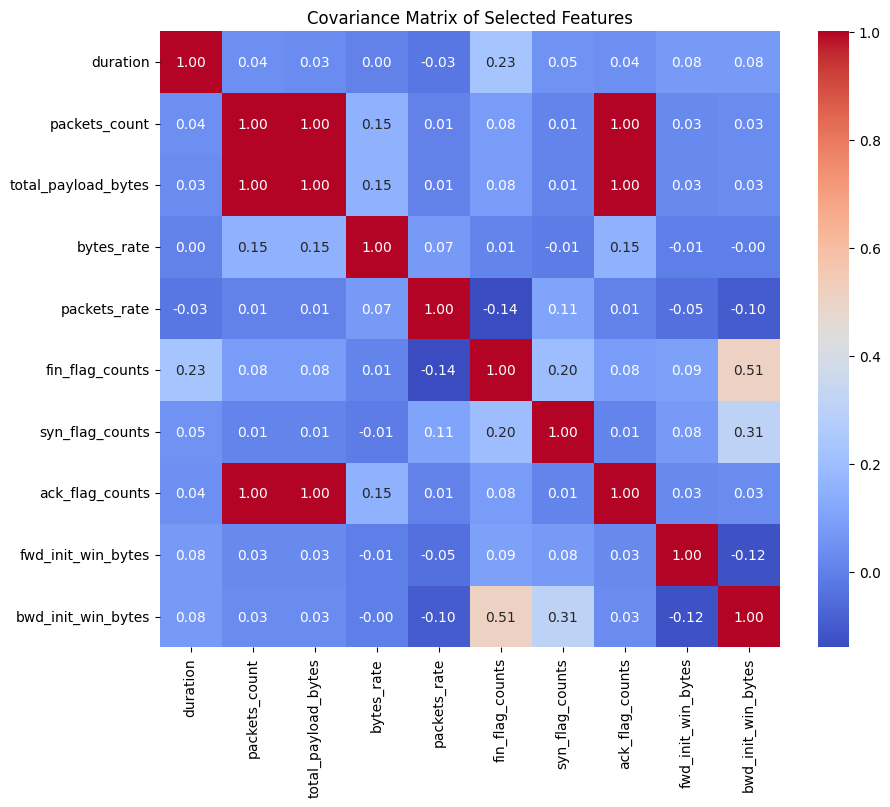

In [ ]:
# --- Appendix Block A: Calculate and Visualize the Covariance Matrix ---
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("--- Step A: Calculating the Covariance Matrix ---")

# --- 1. Select a Sample of Features and Data ---
# We select a few interesting features to make the matrix understandable
features_to_sample = [
    'duration', 'packets_count', 'total_payload_bytes', 'bytes_rate',
    'packets_rate', 'fin_flag_counts', 'syn_flag_counts', 'ack_flag_counts',
    'fwd_init_win_bytes', 'bwd_init_win_bytes'
]

# Take a random sample of 5000 rows to speed up calculations
data_sample = X_raw[features_to_sample].sample(n=5000, random_state=42)

# --- 2. Scale the Sample ---
# Covariance is sensitive to scale, so we must scale the data first.
scaler_sample = StandardScaler()
data_scaled_sample = scaler_sample.fit_transform(data_sample)

# --- 3. Calculate the Covariance Matrix ---
# np.cov expects features as rows, so we need to transpose (.T) our data
covariance_matrix = np.cov(data_scaled_sample.T)

print("Covariance Matrix calculated successfully.")
print(f"Shape of the covariance matrix: {covariance_matrix.shape}")


# --- 4. Visualize the Covariance Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=features_to_sample, yticklabels=features_to_sample)
plt.title('Covariance Matrix of Selected Features')
plt.show()

**Block A1: Determinant of the Covariance Matrix**

In [ ]:
import numpy as np

# This assumes 'covariance_matrix' exists from your previous appendix blocks.

# Calculate the determinant
determinant = np.linalg.det(covariance_matrix)

print("--- Calculating the Determinant ---")
print(f"The determinant of the covariance matrix is: {determinant:.6f}")
print("\nInterpretation:")
print("This value represents the 'generalized variance' or the volume of the data cloud in 10-D space.")

--- Calculating the Determinant ---
The determinant of the covariance matrix is: 0.000000

Interpretation:
This value represents the 'generalized variance' or the volume of the data cloud in 10-D space.


**Appendix Block B: Perform Eigen-Decomposition**

In [ ]:
import numpy as np

print("--- Step B: Decomposing the Covariance Matrix ---")

# This one function solves for all eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

print("Eigen-decomposition successful.")

print(f"\nShape of eigenvalues vector: {eigenvalues.shape}")
print("These are the magnitudes (importance) of each new axis:")
print(eigenvalues)

print(f"\nShape of eigenvectors matrix: {eigenvectors.shape}")
print("Each COLUMN of this matrix is a new axis (a Principal Component):")
# We'll print the first eigenvector (the most important one)
print("First Eigenvector (Principal Component 1):\n", eigenvectors[:, 0])

--- Step B: Decomposing the Covariance Matrix ---
Eigen-decomposition successful.

Shape of eigenvalues vector: (10,)
These are the magnitudes (importance) of each new axis:
[3.05401027 1.76005388 1.1377693  1.08089415 0.97100878 0.90897711
 0.67754736 0.41168491 0.00005465 0.        ]

Shape of eigenvectors matrix: (10, 10)
Each COLUMN of this matrix is a new axis (a Principal Component):
First Eigenvector (Principal Component 1):
 [0.04350287 0.56872425 0.56854061 0.12560655 0.00050909 0.08898295
 0.02708747 0.56872416 0.02676702 0.05319017]


**Block B1: Demonstrating Orthogonality of Eigenvectors**

In [ ]:
import numpy as np

# Get the first two principal components (the first two eigenvectors)
pc1 = sorted_eigenvectors[:, 0]
pc2 = sorted_eigenvectors[:, 1]

# Calculate the dot product
dot_product = np.dot(pc1, pc2)

print("--- Demonstrating Orthogonality ---")
print(f"The dot product of the first two Principal Components is: {dot_product:.15f}")

if np.isclose(dot_product, 0):
    print("The result is very close to zero, confirming that the vectors are orthogonal.")
else:
    print("The result is not zero, which is unexpected.")

--- Demonstrating Orthogonality ---
The dot product of the first two Principal Components is: 0.000000000000000
The result is very close to zero, confirming that the vectors are orthogonal.


**Appendix Block C: Sort Eigen-pairs and Calculate Explained Variance**

--- Step C: Sorting Eigen-pairs and Visualizing Importance ---
Explained Variance Ratio for each Principal Component:
  Component 1: 0.3053 (30.53%)
  Component 2: 0.1760 (17.60%)
  Component 3: 0.1138 (11.38%)
  Component 4: 0.1081 (10.81%)
  Component 5: 0.0971 (9.71%)
  Component 6: 0.0909 (9.09%)
  Component 7: 0.0677 (6.77%)
  Component 8: 0.0412 (4.12%)
  Component 9: 0.0000 (0.00%)
  Component 10: 0.0000 (0.00%)


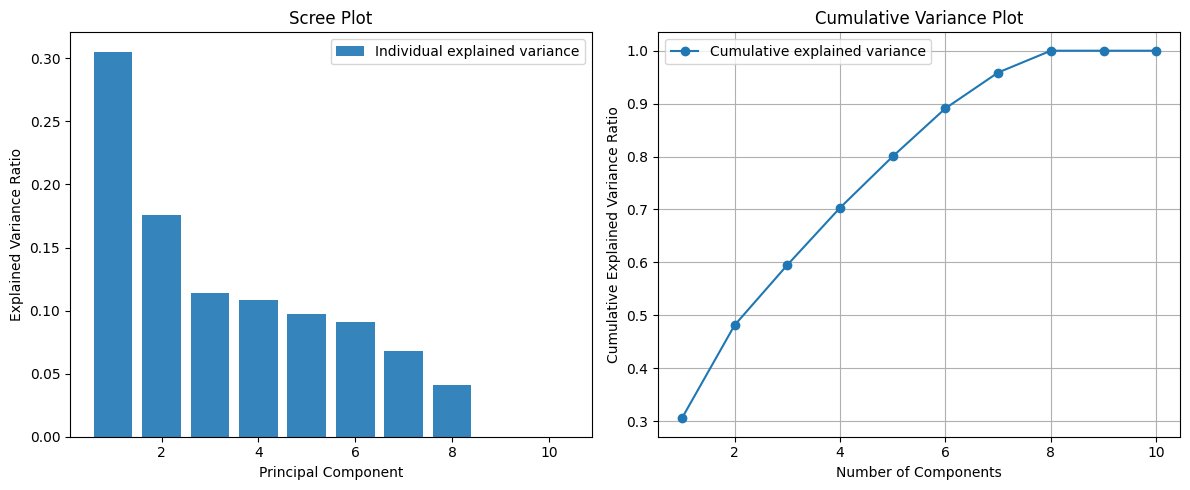

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Step C: Sorting Eigen-pairs and Visualizing Importance ---")

# --- 1. Sort Eigenvalues and Eigenvectors ---
# Get the indices that would sort the eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Use these indices to sort both the eigenvalues and eigenvectors
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# --- 2. Calculate Explained Variance ---
total_eigenvalues = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_eigenvalues
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"  Component {i+1}: {ratio:.4f} ({ratio:.2%})")

# --- 3. Visualize the Results ---
plt.figure(figsize=(12, 5))

# Plot 1: Individual Explained Variance (Scree Plot)
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.9,
        label='Individual explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.legend(loc='best')

# Plot 2: Cumulative Explained Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o',
         label='Cumulative explained variance')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.title('Cumulative Variance Plot')
plt.grid(True)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

**Appendix Block D: Create Projection Matrix and Transform Data**

In [ ]:
import numpy as np

print("--- Step D: Projecting Data into 2D Space ---")

# --- 1. Create the Projection Matrix (W) ---
# We select the first two columns (the top 2 eigenvectors)
# from our sorted eigenvector matrix.
projection_matrix_W = sorted_eigenvectors[:, :2]

# --- 2. Project the Original Data ---
# We perform the dot product: Original Data (5000x10) @ Projection Matrix (10x2)
# The result will be our new data in 2D (5000x2)
data_projected = np.dot(data_scaled_sample, projection_matrix_W)

print("Data projected successfully")

# --- 3. Verify the Shapes ---
print(f"\nShape of original scaled data: {data_scaled_sample.shape}")
print(f"Shape of projection matrix W:   {projection_matrix_W.shape}")
print(f"Shape of new projected data:    {data_projected.shape}")

print("\nFirst 5 rows of the new 2D data:")
print(data_projected[:5, :])

--- Step D: Projecting Data into 2D Space ---
Data projected successfully

Shape of original scaled data: (5000, 10)
Shape of projection matrix W:   (10, 2)
Shape of new projected data:    (5000, 2)

First 5 rows of the new 2D data:
[[-0.15519223  1.0099068 ]
 [-0.15613901  1.01151898]
 [-0.13817538  0.80771481]
 [ 0.4124271  -3.24659547]
 [ 0.0146434  -0.9890775 ]]


**Block D1: Demonstrating a Linear Transformation**

In [ ]:
import numpy as np

# Take a single data point (the first sample) from our 10-D space
original_point = data_scaled_sample[0, :]

# Apply the linear transformation using the projection matrix
transformed_point = np.dot(original_point, projection_matrix_W)

print("--- Demonstrating a Linear Transformation ---")
print(f"Original point coordinates (in 10-D space):\n{original_point}")
print(f"\nTransformed point coordinates (in 2-D space):\n{transformed_point}")
print("\nConclusion: We used a (10x2) matrix to transform a 10-D vector into a 2-D vector.")

--- Demonstrating a Linear Transformation ---
Original point coordinates (in 10-D space):
[-0.06518295 -0.02036033 -0.01995577 -0.01848457 -0.38966963 -0.37220587
 -1.04232515 -0.02032706 -0.7712449  -0.62705196]

Transformed point coordinates (in 2-D space):
[-0.15519223  1.0099068 ]

Conclusion: We used a (10x2) matrix to transform a 10-D vector into a 2-D vector.


**Appendix Block E: Visualize the 2D Projected Data**

--- Step E: Visualizing the Transformed Data in 2D ---


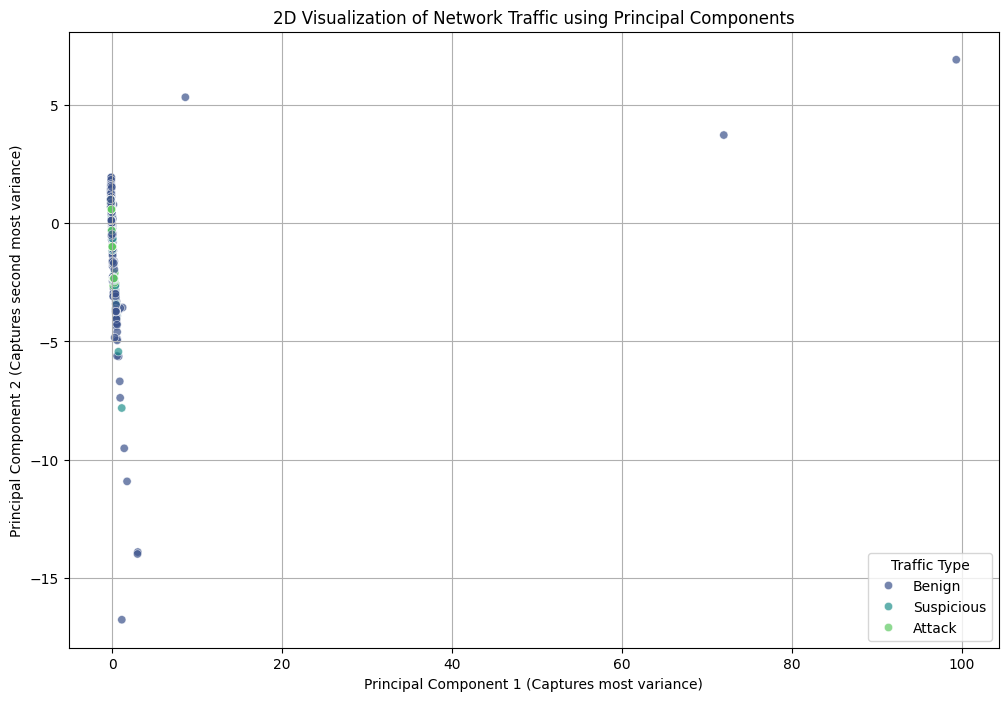

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step E: Visualizing the Transformed Data in 2D ---")

# --- 1. Get the Labels for our Data Sample ---
# We use the index from our original sample to get the correct corresponding labels
sample_labels = y_multiclass.loc[data_sample.index]

# --- 2. Create a DataFrame for Plotting ---
df_projected = pd.DataFrame(data_projected, columns=['Principal Component 1', 'Principal Component 2'])
df_projected['label'] = sample_labels.values
df_projected['label'] = df_projected['label'].map({0: 'Benign', 1: 'Attack', 2: 'Suspicious'}) # Map numbers back to names for the legend

# --- 3. Create the Scatter Plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='label',
    data=df_projected,
    alpha=0.7,
    palette='viridis'
)

plt.title('2D Visualization of Network Traffic using Principal Components')
plt.xlabel('Principal Component 1 (Captures most variance)')
plt.ylabel('Principal Component 2 (Captures second most variance)')
plt.grid(True)
plt.legend(title='Traffic Type')
plt.show()

**Appendix Block F: Solving for Coefficients using the Normal Equation**

In [ ]:
import numpy as np
import pandas as pd

print("--- Step F: Solving for Coefficients using the Normal Equation ---")

# --- 1. Simplify the problem for demonstration ---
# We select a binary problem (Benign=0, Attack=1) and only two features.
binary_df = pd.DataFrame(X_raw) # Create a DataFrame from the numpy array
binary_df['label'] = y_multiclass

# Filter for only Benign (0) and Attack (1)
binary_df = binary_df[binary_df['label'] <= 1]

# Use two simple features for visualization
features = ['duration', 'packets_count']
# Find the original column indices for our features
feature_indices = [X_raw.columns.get_loc(col) for col in features]
X_simple = binary_df.iloc[:, feature_indices].values
y_simple = binary_df['label'].values

# --- 2. Prepare the data for the Normal Equation ---
# Add a 'bias' term (a column of ones) to X for the intercept
X_b = np.c_[np.ones((len(X_simple), 1)), X_simple]

# --- 3. Solve the Normal Equation: θ = (XᵀX)⁻¹Xᵀy ---
# This is the explicit, one-line solution for 'Ax=b'
try:
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_simple)
    print("Normal Equation solved successfully!")
    print("\nThe calculated coefficients (theta) are:")
    print(f"  θ₀ (Bias/Intercept): {theta[0]:.6f}")
    print(f"  θ₁ (Weight for '{features[0]}'): {theta[1]:.6f}")
    print(f"  θ₂ (Weight for '{features[1]}'): {theta[2]:.6f}")

except np.linalg.LinAlgError:
    print("Error: Could not solve the Normal Equation.")
    print("This often happens if features are perfectly correlated (Singular Matrix).")
    theta = None

--- Step F: Solving for Coefficients using the Normal Equation ---
Normal Equation solved successfully!

The calculated coefficients (theta) are:
  θ₀ (Bias/Intercept): 0.356429
  θ₁ (Weight for 'duration'): -0.000078
  θ₂ (Weight for 'packets_count'): -0.000000


**Appendix Block G: Visualize the Normal Equation's Decision Boundary**

--- Step G: Visualizing the Decision Boundary ---


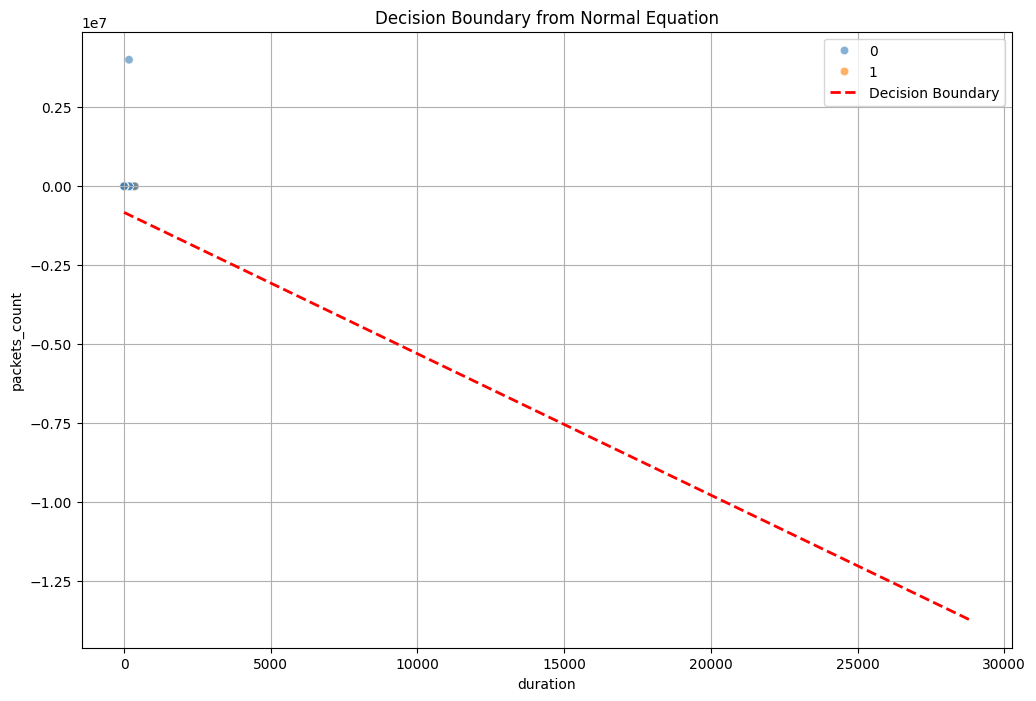

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- Step G: Visualizing the Decision Boundary ---")

# --- 1. Prepare data for plotting ---
# To make the plot readable, we'll take a random sample of the data
plot_df = pd.DataFrame(X_simple, columns=features)
plot_df['label'] = y_simple
plot_sample = plot_df.sample(n=5000, random_state=42)

# --- 2. Create the scatter plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=features[0],
    y=features[1],
    hue='label',
    data=plot_sample,
    alpha=0.6,
    palette=['#377eb8', '#ff7f00'] # Blue for Benign (0), Orange for Attack (1)
)
plt.title('Decision Boundary from Normal Equation')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title='Traffic Type', labels=['Benign', 'Attack'])
plt.grid(True)


# --- 3. Calculate and draw the decision boundary ---
# The decision boundary is the line where θ₀ + θ₁x₁ + θ₂x₂ = 0.5
if theta is not None:
    # Check if theta[2] is close to zero to avoid division errors and handle vertical/horizontal lines
    if np.abs(theta[2]) < 1e-9:
        # Draw a vertical line if weight for y-axis is zero
        boundary_x = (0.5 - theta[0]) / theta[1]
        plt.axvline(x=boundary_x, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        print(f"Since θ₂ is near zero, the boundary is a vertical line at '{features[0]}' = {boundary_x:.2f}")
    elif np.abs(theta[1]) < 1e-9:
        # Draw a horizontal line if weight for x-axis is zero
        boundary_y = (0.5 - theta[0]) / theta[2]
        plt.axhline(y=boundary_y, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        print(f"Since θ₁ is near zero, the boundary is a horizontal line at '{features[1]}' = {boundary_y:.2f}")
    else:
        # For the general case (a sloped line)
        x_values = np.array([np.min(X_simple[:,0]), np.max(X_simple[:,0])])
        y_values = (0.5 - theta[0] - theta[1] * x_values) / theta[2]
        plt.plot(x_values, y_values, "r--", linewidth=2, label='Decision Boundary')

    plt.legend()

plt.show()

**Appendix Block H: The Final Comparison Plot**

--- Final Comparison: Normal Equation vs. PCA ---


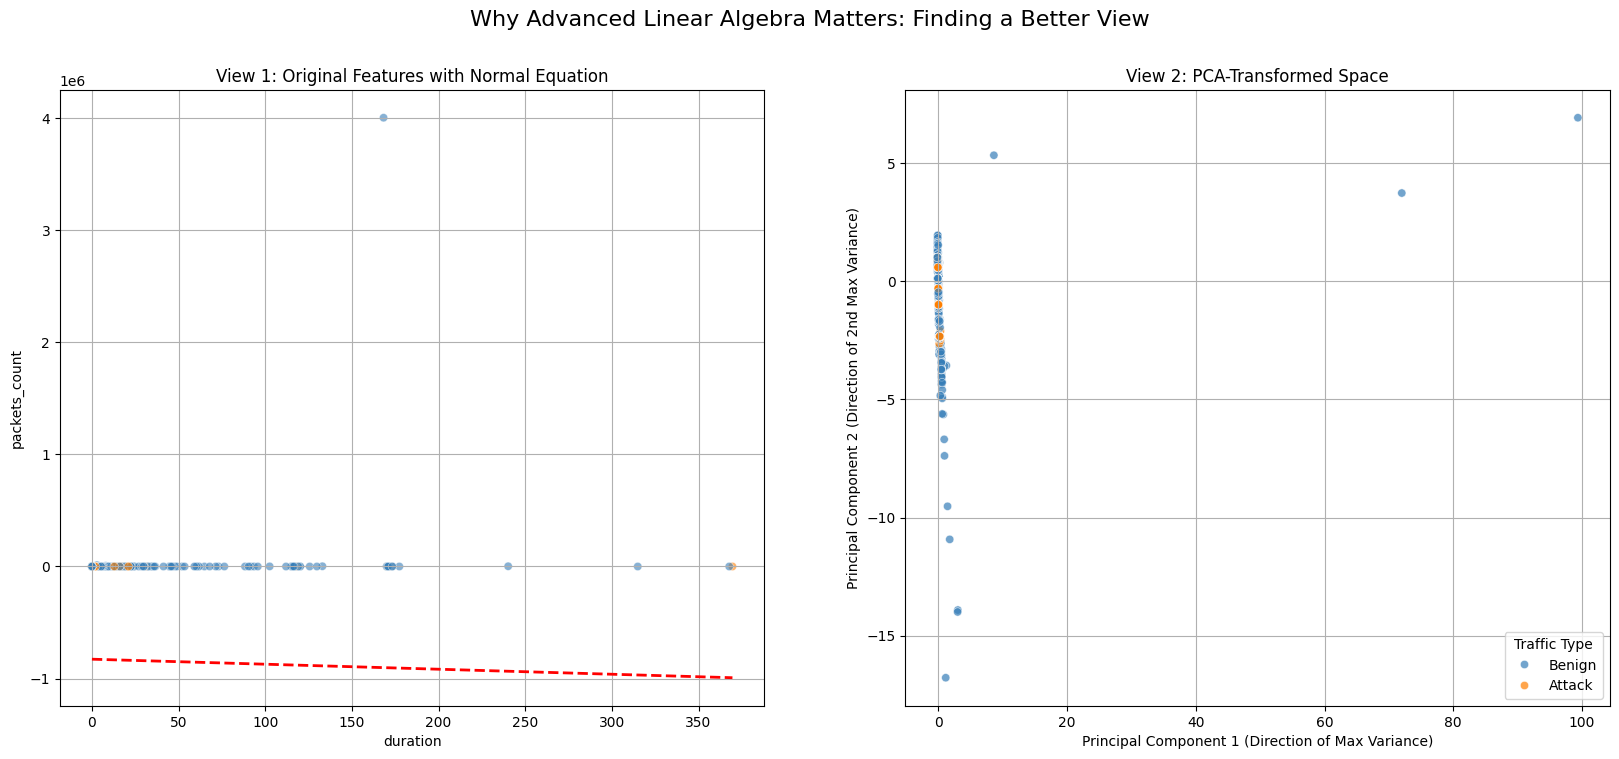

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- Final Comparison: Normal Equation vs. PCA ---")

# This block assumes all necessary variables from previous steps are loaded
# (e.g., plot_sample, theta, df_projected, features)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


# --- Plot 1: The Normal Equation Result ---
sns.scatterplot(
    x=features[0], y=features[1], hue='label', data=plot_sample,
    alpha=0.6, palette=['#377eb8', '#ff7f00'], ax=ax1,
    legend=False # Hide legend for this plot
)
ax1.set_title('View 1: Original Features with Normal Equation')
ax1.set_xlabel(features[0])
ax1.set_ylabel(features[1])
ax1.grid(True)

# Re-draw the decision boundary line
if 'theta' in locals() and theta is not None:
    # Check if the coefficient for the y-axis feature is near zero
    if np.abs(theta[2]) < 1e-9:
        boundary_x = (0.5 - theta[0]) / theta[1]
        ax1.axvline(x=boundary_x, color='red', linestyle='--', linewidth=2)
    else:
        # Calculate for a standard sloped line
        x_values = np.array([plot_sample[features[0]].min(), plot_sample[features[0]].max()])
        y_values = (0.5 - theta[0] - theta[1] * x_values) / theta[2]
        ax1.plot(x_values, y_values, "r--", linewidth=2)


# --- Plot 2: The PCA Result ---
# Filter the projected data for a fair comparison (only Benign and Attack)
pca_binary_df = df_projected[df_projected['label'].isin(['Benign', 'Attack'])]

sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2', hue='label',
    data=pca_binary_df, alpha=0.7, palette=['#377eb8', '#ff7f00'], ax=ax2
)
ax2.set_title('View 2: PCA-Transformed Space')
ax2.set_xlabel('Principal Component 1 (Direction of Max Variance)')
ax2.set_ylabel('Principal Component 2 (Direction of 2nd Max Variance)')
ax2.grid(True)
ax2.legend(title='Traffic Type')


# Add a main title for the entire figure
plt.suptitle('Why Advanced Linear Algebra Matters: Finding a Better View', fontsize=16)
plt.show()

**Appendix Block I: Analysis of Rank and Basis Spaces**

In [ ]:
# --- Appendix Block I: Analysis of Rank and Basis Spaces ---
from scipy.linalg import svd
import numpy as np

# This assumes 'data_scaled_sample' (the 5000x10 scaled data) exists.

print(f"--- Calculating the Rank of the Data Sample ---")
# Calculate the rank of the matrix using NumPy's linear algebra module
matrix_rank = np.linalg.matrix_rank(data_scaled_sample)

print(f"The shape of our data matrix is: {data_scaled_sample.shape}")
print(f"The calculated rank of the matrix is: {matrix_rank}")

if matrix_rank < data_scaled_sample.shape[1]:
    print("\nConclusion: Since the rank is less than the number of columns,")
    print("it indicates that some of the features are linearly dependent (redundant).")
else:
    print("\nConclusion: Since the rank is equal to the number of columns,")
    print("it indicates that all the selected features are linearly independent.")

print("\n--- Finding a Basis for the Spaces using SVD ---")
# Perform Singular Value Decomposition
# U corresponds to the Column Space, Vh corresponds to the Row Space
U, s, Vh = svd(data_scaled_sample, full_matrices=False)

# The columns of U form a basis for the Column Space
# We take the first 'rank' columns
column_space_basis = U[:, :matrix_rank]

# The rows of Vh form a basis for the Row Space
# We take the first 'rank' rows
row_space_basis = Vh[:matrix_rank, :]

print(f"\nA basis for the Column Space is a set of {column_space_basis.shape[1]} vectors, each of dimension {column_space_basis.shape[0]}.")
print("First basis vector for the Column Space:\n", column_space_basis[:, 0])

print(f"\nA basis for the Row Space is a set of {row_space_basis.shape[0]} vectors, each of dimension {row_space_basis.shape[1]}.")
print("First basis vector for the Row Space:\n", row_space_basis[0, :])

--- Calculating the Rank of the Data Sample ---
The shape of our data matrix is: (5000, 10)
The calculated rank of the matrix is: 10

Conclusion: Since the rank is equal to the number of columns,
it indicates that all the selected features are linearly independent.

--- Finding a Basis for the Spaces using SVD ---

A basis for the Column Space is a set of 10 vectors, each of dimension 5000.
First basis vector for the Column Space:
 [-0.00125601 -0.00126367 -0.00111829 ... -0.00060838  0.0016113
 -0.00060838]

A basis for the Row Space is a set of 10 vectors, each of dimension 10.
First basis vector for the Row Space:
 [0.04350287 0.56872425 0.56854061 0.12560655 0.00050909 0.08898295
 0.02708747 0.56872416 0.02676702 0.05319017]


**Appendix Block J: Second Theoretical Example (Linear Regression via Least Squares)**

In [ ]:
# with .iloc fix
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# --- Create a subsample using a direct NumPy method ---
print("Creating a smaller subsample for the least squares calculation...")

# Define the number of samples we want
num_samples = 50000
# Get the total number of rows available
total_rows = X_train.shape[0]

# Generate random, unique row indices
random_indices = np.random.choice(total_rows, size=num_samples, replace=False)

# Use these indices to select the rows directly
X_train_lstsq_sample = X_train[random_indices]
# Use .iloc to select by integer position from the pandas Series
y_train_lstsq_sample = y_train.iloc[random_indices]

print("Subsample created successfully.")

# --- The original demonstration code, now running on the smaller sample ---
print("\nSolving Ax = b using least squares on the subsample...")
x_sol, residuals, rank, s = np.linalg.lstsq(X_train_lstsq_sample, y_train_lstsq_sample, rcond=None)

print("Solution x (coefficients) found.")

# Predict on the test set
y_pred = np.dot(X_test, x_sol)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Creating a smaller subsample for the least squares calculation...
Subsample created successfully.

Solving Ax = b using least squares on the subsample...
Solution x (coefficients) found.

Mean Squared Error (MSE): 1883.6483
R² Score: -4498.2285


**Evaluation of the Hybrid PCA-SVM Model**

---


*  The Hybrid PCA-SVM model demonstrates remarkable power in significantly reducing false alarms when classifying DoS attacks. Although the Random Forest model outperformed the model in detecting a larger number of actual attacks (higher recall), the PCA-SVM results remain comparable and robust, especially in its high accuracy when identifying attacks (precision).

*   This project demonstrates that linear algebra, represented by the PCA technique, makes a valuable and effective contribution to simplifying the problem of classifying high-dimensional DoS attacks, allowing models like SVM to operate efficiently and achieve good results.

*   This approach is also scalable and optimizable. By using linear discriminant analysis (LDA) instead of PCA, which focuses on finding dimensions that increase class separability, it is possible to improve the model's ability to detect more actual attacks (increased recall) while maintaining its advantage in reducing false alarms. This could make it a stronger competitor to the Random Forest model.
